# 06b - Double Poisson Models for Binary Prediction

This notebook applies the double Poisson framework to the binary task
**home win (`1`) vs. away not lose (`0`)**.
The score matrix is still modeled explicitly, but the final decision rule is binary.

## 1. Imports and Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.data_builder import attach_fbref_match_metadata
from src.double_poisson import DoublePoissonRegressor, get_double_poisson_model_space, run_double_poisson_backtest, run_static_double_poisson_screening, fit_final_double_poisson_model, top_scorelines_from_matrix
from src.ml_modeling import score_predictions, build_class_metrics_table
from src.run_artifacts import save_run_artifacts, save_deployment_model
from src.rolling_backtest import evaluate_by_matchday, summarize_predictions


## 2. Load the Advanced Match Table

In [2]:
features_path = PROCESSED_DATA_DIR / 'match_features_advanced.parquet'
if not features_path.exists():
    features_path = PROCESSED_DATA_DIR / 'match_features_advanced.csv'

try:
    df = pd.read_parquet(features_path) if features_path.suffix == '.parquet' else pd.read_csv(features_path)
except Exception:
    df = pd.read_csv(PROCESSED_DATA_DIR / 'match_features_advanced.csv')

df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'matchday' not in df.columns:
    fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.parquet'
    if not fbref_schedule_path.exists():
        fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.csv'

    try:
        fbref_schedule = pd.read_parquet(fbref_schedule_path) if fbref_schedule_path.suffix == '.parquet' else pd.read_csv(fbref_schedule_path)
    except Exception:
        fbref_schedule = pd.read_csv(RAW_DATA_DIR / 'fbref' / 'schedule.csv')

    df = attach_fbref_match_metadata(df, fbref_schedule)

preview_cols = [
    col for col in [
        'date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'home_win', 'matchday'
    ]
    if col in df.columns
]

print('Dataset shape:', df.shape)
print(f"Matchday coverage: {df['matchday'].notna().mean():.1%}" if 'matchday' in df.columns else 'Matchday column unavailable')
display(df[preview_cols].head())


Dataset shape: (882, 252)
Matchday coverage: 85.1%


,date,home_team,away_team,home_goals,away_goals,home_win,matchday
0,2023-08-18 18:30:00,Werder Bremen,Bayern Munich,0,4,0,1
1,2023-08-19 13:30:00,Bayer Leverkusen,RasenBallsport Leipzig,3,2,1,1
2,2023-08-19 13:30:00,Wolfsburg,FC Heidenheim,2,0,1,1
3,2023-08-19 13:30:00,Hoffenheim,Freiburg,1,2,0,1
4,2023-08-19 13:30:00,Augsburg,Borussia M.Gladbach,4,4,0,1


## 3. Define the Binary Target

The target is `home_win`.
The complementary class therefore corresponds to the market-style `away not lose` event.

In [3]:
TARGET_COL = 'home_win'
RUN_KEY = 'double_poisson_binary'
TARGET_LABEL_MAP = {1: 'Home win', 0: 'Away not lose'}
print(df[TARGET_COL].value_counts(normalize=True).rename('share'))

home_win
0    0.579365
1    0.420635
Name: share, dtype: float64


## 4. Define the Poisson Model Space and Static Screening

In [4]:
POISSON_MODEL_SPACE = get_double_poisson_model_space()
POISSON_BACKTEST_CONFIG = {'test_season_id': 2025, 'min_train_size': 100}
poisson_screening = run_static_double_poisson_screening(
    df=df,
    model_space=POISSON_MODEL_SPACE,
    target_col=TARGET_COL,
    outcome_mode='binary_home_win',
    threshold=0.5,
    primary_metric='accuracy',
)
display(poisson_screening)

,model,accuracy,macro_f1,weighted_f1,alpha,max_goals,avg_lambda_home,avg_lambda_away
0,double_poisson_alpha_0_1,0.725146,0.673518,0.716795,0.1,10,1.757967,1.483879
1,double_poisson_alpha_0_5,0.666667,0.416242,0.543690,0.5,10,1.698319,1.545303
2,double_poisson_alpha_1_0,0.666667,0.400000,0.533333,1.0,10,1.671015,1.572322
3,double_poisson_alpha_2_0,0.666667,0.400000,0.533333,2.0,10,1.650423,1.592710


## 5. Run the Rolling Backtests

In [5]:
poisson_outputs = {}
for model_name, model_config in POISSON_MODEL_SPACE.items():
    print(f'Running {model_name}...')
    predictions, fit_summary = run_double_poisson_backtest(
        df=df,
        model_name=model_name,
        model_config=model_config,
        target_col=TARGET_COL,
        outcome_mode='binary_home_win',
        threshold=0.5,
        **POISSON_BACKTEST_CONFIG,
    )
    results = summarize_predictions(predictions)
    poisson_outputs[model_name] = {
        'predictions': predictions,
        'fit_summary': fit_summary,
        'results': results,
        'config': model_config,
    }

all_predictions = pd.concat([payload['predictions'] for payload in poisson_outputs.values()], ignore_index=True)
all_fit_summaries = pd.concat([payload['fit_summary'] for payload in poisson_outputs.values()], ignore_index=True)
all_model_results = pd.concat([payload['results'] for payload in poisson_outputs.values()], ignore_index=True).sort_values(['accuracy', 'macro_f1'], ascending=False).reset_index(drop=True)
all_model_results

Running double_poisson_alpha_0_1...
Running double_poisson_alpha_0_5...
Running double_poisson_alpha_1_0...
Running double_poisson_alpha_2_0...


,model,accuracy,macro_f1,weighted_f1
0,double_poisson_alpha_0_1,0.696296,0.656403,0.670279
1,double_poisson_alpha_0_5,0.559259,0.358670,0.401179
2,double_poisson_alpha_1_0,0.559259,0.358670,0.401179
3,double_poisson_alpha_2_0,0.559259,0.358670,0.401179


## 6. Fit Diagnostics Across Batches

In [6]:
fit_diagnostics = (
    all_fit_summaries.groupby('model')
    .agg(
        mean_intercept_log_rate=('intercept_log_rate', 'mean'),
        mean_home_advantage=('home_advantage_log_effect', 'mean'),
        n_batches=('batch_id', 'nunique'),
        mean_history_size=('n_history_matches', 'mean'),
    )
    .reset_index()
    .merge(all_model_results[['model', 'accuracy', 'macro_f1']], on='model', how='left')
)
fit_diagnostics.sort_values(['accuracy', 'mean_home_advantage'], ascending=[False, False])

,model,mean_intercept_log_rate,mean_home_advantage,n_batches,mean_history_size,accuracy,macro_f1
0,double_poisson_alpha_0_1,0.377470,0.134556,164,747.060976,0.696296,0.656403
1,double_poisson_alpha_0_5,0.424242,0.074567,164,747.060976,0.559259,0.358670
2,double_poisson_alpha_1_0,0.439576,0.047903,164,747.060976,0.559259,0.358670
3,double_poisson_alpha_2_0,0.450375,0.027937,164,747.060976,0.559259,0.358670


## 7. Accuracy by Bundesliga Matchday

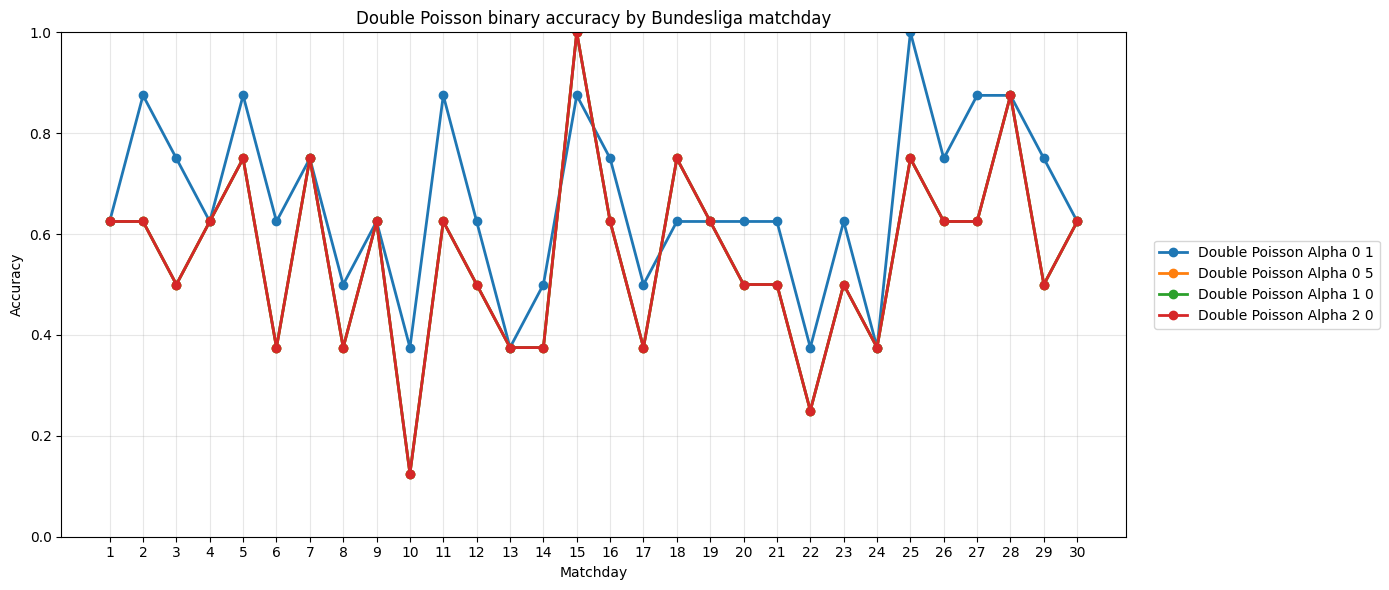

,model,matchday,n_matches,accuracy,macro_f1,weighted_f1
0,double_poisson_alpha_0_1,1,8,0.625,0.563636,0.604545
1,double_poisson_alpha_0_1,2,8,0.875,0.854545,0.868182
2,double_poisson_alpha_0_1,3,8,0.750,0.733333,0.733333
3,double_poisson_alpha_0_1,4,8,0.625,0.619048,0.630952
4,double_poisson_alpha_0_1,5,8,0.875,0.794872,0.858974
...,...,...,...,...,...,...
115,double_poisson_alpha_2_0,26,8,0.625,0.384615,0.480769
116,double_poisson_alpha_2_0,27,8,0.625,0.384615,0.480769
117,double_poisson_alpha_2_0,28,8,0.875,0.466667,0.816667
118,double_poisson_alpha_2_0,29,8,0.500,0.333333,0.333333


In [7]:
accuracy_by_matchday = evaluate_by_matchday(all_predictions)
fig, ax = plt.subplots(figsize=(14, 6))
for model_name, group in accuracy_by_matchday.groupby('model'):
    ax.plot(group['matchday'], group['accuracy'], marker='o', linewidth=2, label=model_name.replace('_', ' ').title())
ax.set_title('Double Poisson binary accuracy by Bundesliga matchday')
ax.set_xlabel('Matchday')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(sorted(accuracy_by_matchday['matchday'].dropna().unique()))
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()
accuracy_by_matchday

## 8. Best-Model Diagnostics

In [8]:
best_model_name = all_model_results.iloc[0]['model']
best_payload = poisson_outputs[best_model_name]
best_predictions = best_payload['predictions'].copy()
best_fit_summary = best_payload['fit_summary'].copy()
best_metrics = score_predictions(best_predictions['target'], best_predictions['y_pred'])
best_class_metrics = build_class_metrics_table(best_metrics['classification_report_dict'])
best_class_metrics['class_name'] = best_class_metrics['class'].astype(int).map(TARGET_LABEL_MAP)

print('Best model:', best_model_name)
display(all_model_results[all_model_results['model'] == best_model_name])
display(best_fit_summary.head())
display(best_class_metrics)

Best model: double_poisson_alpha_0_1


,model,accuracy,macro_f1,weighted_f1
0,double_poisson_alpha_0_1,0.696296,0.656403,0.670279


,batch_id,kickoff_time,model,n_history_matches,alpha,max_goals,intercept_log_rate,home_advantage_log_effect
0,1,2025-08-22 18:30:00,double_poisson_alpha_0_1,612,0.1,10,0.375459,0.133373
1,2,2025-08-23 13:30:00,double_poisson_alpha_0_1,613,0.1,10,0.374219,0.137474
2,3,2025-08-23 16:30:00,double_poisson_alpha_0_1,618,0.1,10,0.377417,0.135070
3,4,2025-08-24 13:30:00,double_poisson_alpha_0_1,619,0.1,10,0.379475,0.135012
4,5,2025-08-24 15:30:00,double_poisson_alpha_0_1,620,0.1,10,0.378930,0.133905


,class,precision,recall,f1_score,support,class_name
0,0,0.663507,0.927152,0.773481,151.0,Away not lose
1,1,0.813559,0.403361,0.539326,119.0,Home win


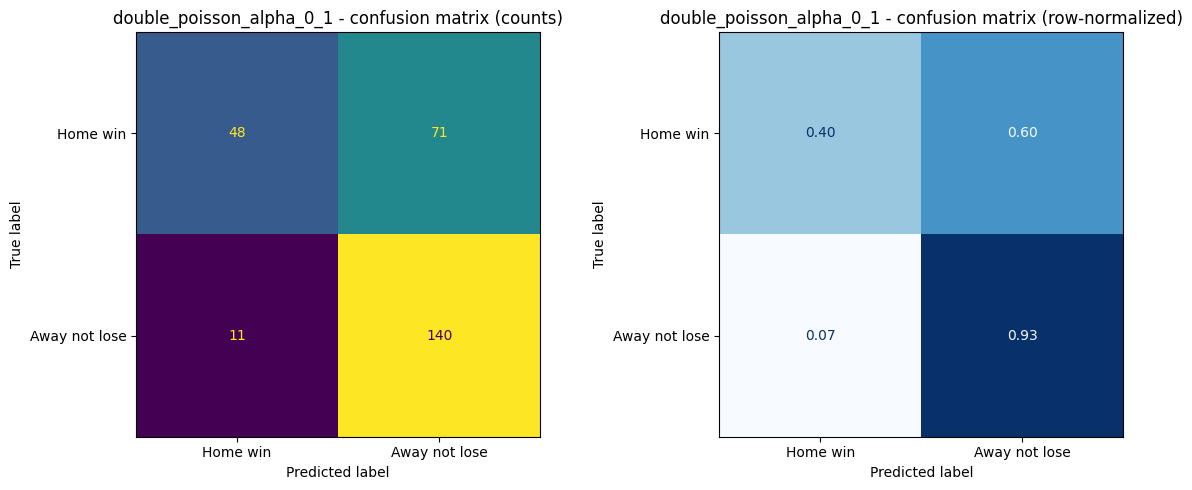

In [9]:
labels = [1, 0]
display_labels = [TARGET_LABEL_MAP[label] for label in labels]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=labels), display_labels=display_labels).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_model_name} - confusion matrix (counts)')
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=labels, normalize='true'), display_labels=display_labels).plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title(f'{best_model_name} - confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

In [10]:
best_errors = best_predictions.loc[
    best_predictions['target'] != best_predictions['y_pred'],
    ['matchday', 'date', 'home_team', 'away_team', 'target', 'y_pred', 'home_win_prob', 'away_not_lose_prob', 'draw_prob', 'away_win_prob', 'predicted_home_goals', 'predicted_away_goals'],
].copy()
best_errors['actual_label'] = best_errors['target'].astype(int).map(TARGET_LABEL_MAP)
best_errors['predicted_label'] = best_errors['y_pred'].astype(int).map(TARGET_LABEL_MAP)
best_errors['error_type'] = best_errors['actual_label'] + ' -> ' + best_errors['predicted_label']
error_breakdown = best_errors['error_type'].value_counts().rename_axis('error_type').to_frame('count')
display(error_breakdown)
display(best_errors.head(15))

,count
error_type,
Home win -> Away not lose,71
Away not lose -> Home win,11


,matchday,date,home_team,away_team,target,y_pred,home_win_prob,away_not_lose_prob,draw_prob,away_win_prob,predicted_home_goals,predicted_away_goals,actual_label,predicted_label,error_type
2,1,2025-08-23 13:30:00,Bayer Leverkusen,Hoffenheim,0,1,0.613858,0.386142,0.191684,0.194458,2,1,Away not lose,Home win,Away not lose -> Home win
3,1,2025-08-23 13:30:00,Union Berlin,VfB Stuttgart,1,0,0.301368,0.698632,0.238870,0.459763,1,1,Home win,Away not lose,Home win -> Away not lose
4,1,2025-08-23 13:30:00,Eintracht Frankfurt,Werder Bremen,1,0,0.475417,0.524583,0.231365,0.293218,1,1,Home win,Away not lose,Home win -> Away not lose
17,2,2025-08-31 17:30:00,FC Cologne,Freiburg,1,0,0.387553,0.612447,0.248968,0.363479,1,1,Home win,Away not lose,Home win -> Away not lose
19,3,2025-09-13 13:30:00,Freiburg,VfB Stuttgart,1,0,0.330220,0.669780,0.232816,0.436964,1,1,Home win,Away not lose,Home win -> Away not lose
25,3,2025-09-14 13:30:00,St. Pauli,Augsburg,1,0,0.427448,0.572552,0.254600,0.317952,1,1,Home win,Away not lose,Home win -> Away not lose
30,4,2025-09-20 13:30:00,Hamburger SV,FC Heidenheim,1,0,0.457876,0.542124,0.237225,0.304899,1,1,Home win,Away not lose,Home win -> Away not lose
33,4,2025-09-21 13:30:00,Eintracht Frankfurt,Union Berlin,0,1,0.516294,0.483706,0.232447,0.251259,1,1,Away not lose,Home win,Away not lose -> Home win
34,4,2025-09-21 15:30:00,Bayer Leverkusen,Borussia M.Gladbach,0,1,0.592960,0.407040,0.200139,0.206901,2,1,Away not lose,Home win,Away not lose -> Home win
37,5,2025-09-27 13:30:00,FC Heidenheim,Augsburg,1,0,0.406975,0.593025,0.244356,0.348669,1,1,Home win,Away not lose,Home win -> Away not lose


## 9. Score-Matrix Diagnostic for One Match

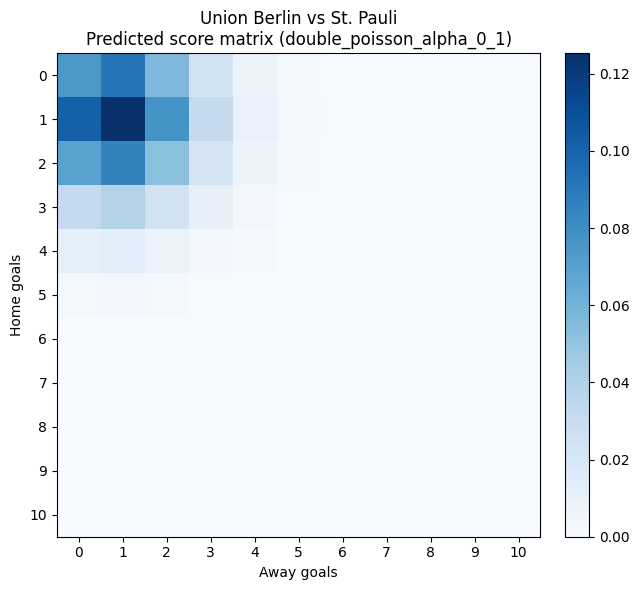

,date,home_team,away_team,home_goals,away_goals,target_1x2,home_win
862,2026-04-05 13:30:00,Union Berlin,St. Pauli,1,1,D,0


,pred_home_goals,pred_away_goals,probability
0,1,1,0.125332
1,1,0,0.101706
2,0,1,0.091938
3,2,1,0.085428
4,1,2,0.077223
5,0,0,0.074607
6,2,0,0.069324
7,0,2,0.056648
8,2,2,0.052636
9,3,1,0.038819


In [11]:
example_match = best_predictions.sort_values('predicted_score_prob', ascending=False).iloc[0]
example_match_df = df[df['game_id'] == example_match['game_id']].copy()
example_history = df[df['date'] < pd.to_datetime(example_match['date'])].copy()
example_model = DoublePoissonRegressor(**POISSON_MODEL_SPACE[best_model_name]).fit(example_history)
example_score_matrix = example_model.predict_score_matrix(example_match_df)
example_top_scorelines = top_scorelines_from_matrix(example_score_matrix, top_n=10)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(example_score_matrix, cmap='Blues')
ax.set_title(
    f"{example_match['home_team']} vs {example_match['away_team']}\n"
    f"Predicted score matrix ({best_model_name})"
)
ax.set_xlabel('Away goals')
ax.set_ylabel('Home goals')
ax.set_xticks(range(example_score_matrix.shape[1]))
ax.set_yticks(range(example_score_matrix.shape[0]))
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(example_match_df[['date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'target_1x2', 'home_win']])
display(example_top_scorelines)


## 10. Save Run Outputs and Persist the Deployment Model

In [12]:
final_fit = fit_final_double_poisson_model(
    df=df,
    model_name=best_model_name,
    model_config=POISSON_MODEL_SPACE[best_model_name],
    target_col=TARGET_COL,
)

run_metadata = {
    'run_key': RUN_KEY,
    'target_col': TARGET_COL,
    'task_type': 'binary_double_poisson',
    'test_season_id': POISSON_BACKTEST_CONFIG['test_season_id'],
    'model_space': POISSON_MODEL_SPACE,
    'best_model_name': best_model_name,
    'deployment_fit_summary': final_fit['fit_summary'],
}

run_dir = save_run_artifacts(
    run_key=RUN_KEY,
    metadata=run_metadata,
    tables={
        'poisson_screening': poisson_screening,
        'all_model_results': all_model_results,
        'all_predictions': all_predictions,
        'all_fit_summaries': all_fit_summaries,
        'fit_diagnostics': fit_diagnostics,
        'accuracy_by_matchday': accuracy_by_matchday,
        'best_model_predictions': best_predictions,
        'best_model_class_metrics': best_class_metrics,
        'best_model_team_strengths': final_fit['team_strengths'],
    },
)

artifact_path = save_deployment_model(
    run_key=RUN_KEY,
    artifact_name='best_model',
    model_object={
        'estimator': final_fit['estimator'],
        'target_col': TARGET_COL,
        'model_name': best_model_name,
    },
    metadata={
        'run_key': RUN_KEY,
        'best_model_name': best_model_name,
        'fit_summary': final_fit['fit_summary'],
    },
)

print('Saved run outputs to:', run_dir)
print('Saved deployment artifact to:', artifact_path)

Saved run outputs to: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\model_runs\double_poisson_binary
Saved deployment artifact to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\models\deployment\double_poisson_binary\best_model.pkl
